## Task A: Dataset Preparation

 Name: Janani K.
 Roll No: 24BAD039



In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Load CIFAR-10 dataset
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training images:", x_train_full.shape)
print("Training labels:", y_train_full.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1577s 9us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [3]:
# Define class names for CIFAR-10
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("Number of classes:", len(class_names))
print("Classes:", class_names)

Number of classes: 10
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


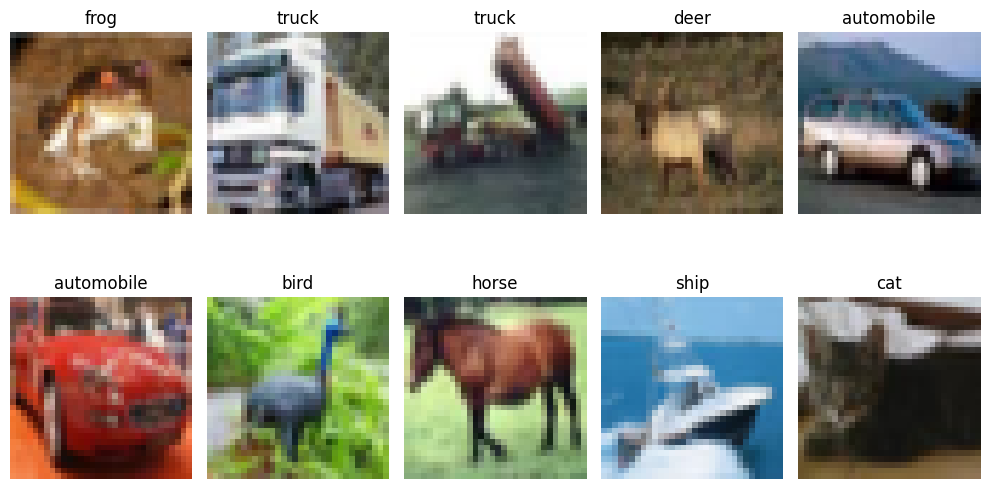

In [4]:
# Visualize some sample images from the training set
plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_full[i])
    plt.title(class_names[y_train_full[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Number of validation samples
validation_size = 5000

# Split the dataset
x_val = x_train_full[:validation_size]
y_val = y_train_full[:validation_size]

x_train = x_train_full[validation_size:]
y_train = y_train_full[validation_size:]

print("Training set:", x_train.shape, y_train.shape)
print("Validation set:", x_val.shape, y_val.shape)
print("Testing set:", x_test.shape, y_test.shape)

Training set: (45000, 32, 32, 3) (45000, 1)
Validation set: (5000, 32, 32, 3) (5000, 1)
Testing set: (10000, 32, 32, 3) (10000, 1)


In [6]:
# Resize images to 64x64 and normalize pixel values to [0, 1]
IMAGE_SIZE = 64

x_train = tf.image.resize(x_train, (IMAGE_SIZE, IMAGE_SIZE))
x_val = tf.image.resize(x_val, (IMAGE_SIZE, IMAGE_SIZE))
x_test = tf.image.resize(x_test, (IMAGE_SIZE, IMAGE_SIZE))

print("Training images after resizing:", x_train.shape)
print("Validation images after resizing:", x_val.shape)
print("Testing images after resizing:", x_test.shape)

Training images after resizing: (45000, 64, 64, 3)
Validation images after resizing: (5000, 64, 64, 3)
Testing images after resizing: (10000, 64, 64, 3)


In [7]:
# Convert pixel values to floating point values
x_train = tf.cast(x_train, tf.float32) / 255.0
x_val = tf.cast(x_val, tf.float32) / 255.0
x_test = tf.cast(x_test, tf.float32) / 255.0

print("Minimum pixel value:", tf.reduce_min(x_train).numpy())
print("Maximum pixel value:", tf.reduce_max(x_train).numpy())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [8]:
#verify the processed data
print("Training data shape:", x_train.shape)
print("Validation data shape:", x_val.shape)
print("Testing data shape:", x_test.shape)

print("\nPixel value range:")
print("Minimum:", tf.reduce_min(x_train).numpy())
print("Maximum:", tf.reduce_max(x_train).numpy())

Training data shape: (45000, 64, 64, 3)
Validation data shape: (5000, 64, 64, 3)
Testing data shape: (10000, 64, 64, 3)

Pixel value range:
Minimum: 0.0
Maximum: 1.0


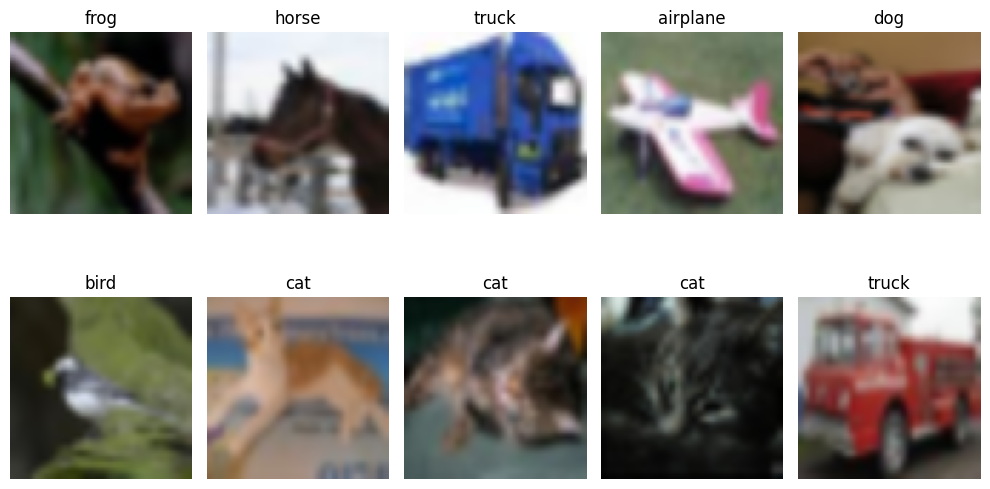

In [9]:
#visulize the processed data
plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Dataset Preparation Summary

The CIFAR-10 dataset was successfully loaded and prepared for CNN training.

### Final Dataset:
- Training images: 45,000
- Validation images: 5,000
- Testing images: 10,000
- Original image size: 32 × 32 × 3
- Resized image size: 64 × 64 × 3
- Pixel value range after normalization: 0–1
- Number of classes: 10

The dataset is now ready for building and training the CNN model.

## Task B: CNN Model Implementation
 Name: Janani K.
 Roll No: 24BAD039

In [10]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [11]:
#Building the CNN architecture
model = Sequential([

    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),

    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Convert feature maps into a 1D vector
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),

    # Output Layer
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,626,442 (6.20 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
#compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [14]:
#verify model configuration
print("Optimizer: Adam")
print("Loss Function: Sparse Categorical Cross-Entropy")
print("Evaluation Metric: Accuracy")

Optimizer: Adam
Loss Function: Sparse Categorical Cross-Entropy
Evaluation Metric: Accuracy


## Task B: Conclusion

A Convolutional Neural Network was successfully implemented using TensorFlow/Keras for CIFAR-10 image classification.

The model consists of convolutional layers for feature extraction, ReLU activation for non-linearity, max pooling layers for dimensionality reduction, a fully connected layer for classification, and a Softmax output layer for predicting the 10 CIFAR-10 classes.

The model was compiled using the Adam optimizer and Sparse Categorical Cross-Entropy loss function with accuracy as the evaluation metric.

The CNN is now ready for training and evaluation.

# TASK C: MODEL TRAINING AND EVALUATION

NAME: Janani K
ROLL NO: 24BAD039

In [15]:
# Number of training epochs
EPOCHS = 10

# Train the CNN model
history = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.4864 - loss: 1.4385 - val_accuracy: 0.5678 - val_loss: 1.2193
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6202 - loss: 1.0803 - val_accuracy: 0.6366 - val_loss: 1.0301
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6817 - loss: 0.9120 - val_accuracy: 0.6588 - val_loss: 0.9712
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7285 - loss: 0.7760 - val_accuracy: 0.6678 - val_loss: 0.9684
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7698 - loss: 0.6607 - val_accuracy: 0.6744 - val_loss: 0.9609
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8104 - loss: 0.5453 - val_accuracy: 0.6748 - val_loss: 0.9900
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8502 - loss: 0.4309 - val_accuracy: 0.6778 - val_loss: 1.0443
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8832 - loss: 0.3325 - val_accuracy: 

In [18]:
# Store training and validation metrics
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']

training_loss = history.history['loss']
validation_loss = history.history['val_loss']

print("Final Training Accuracy:",
      training_accuracy[-1])

print("Final Validation Accuracy:",
      validation_accuracy[-1])

print("Final Training Loss:",
      training_loss[-1])

print("Final Validation Loss:",
      validation_loss[-1])

Final Training Accuracy: 0.9400444626808167
Final Validation Accuracy: 0.6725999712944031
Final Training Loss: 0.17753438651561737
Final Validation Loss: 1.498557448387146


In [19]:
print(f"Final Training Accuracy: {training_accuracy[-1] * 100:.2f}%")
print(f"Final Validation Accuracy: {validation_accuracy[-1] * 100:.2f}%")

print(f"Final Training Loss: {training_loss[-1]:.4f}")
print(f"Final Validation Loss: {validation_loss[-1]:.4f}")

Final Training Accuracy: 94.00%
Final Validation Accuracy: 67.26%
Final Training Loss: 0.1775
Final Validation Loss: 1.4986


In [20]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print(f"\nTesting Loss: {test_loss:.4f}")
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6639 - loss: 1.5499

Testing Loss: 1.5499
Testing Accuracy: 66.39%


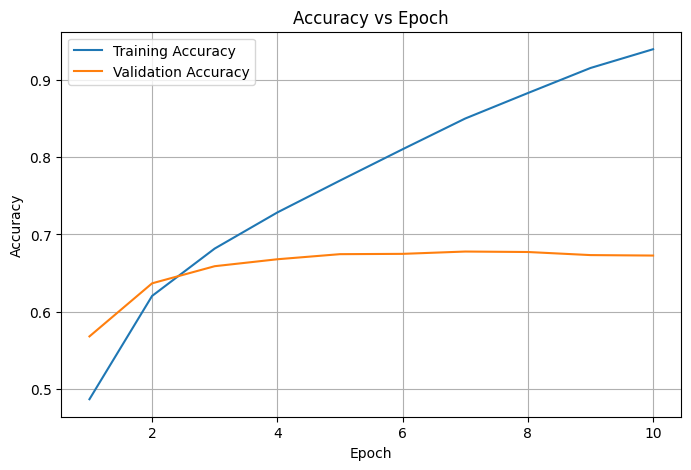

In [21]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    training_accuracy,
    label='Training Accuracy'
)

plt.plot(
    epochs_range,
    validation_accuracy,
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

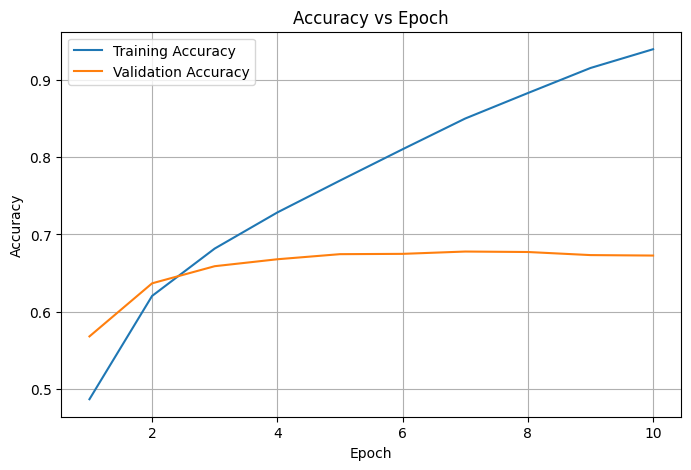

In [22]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    training_accuracy,
    label='Training Accuracy'
)

plt.plot(
    epochs_range,
    validation_accuracy,
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
print("=" * 45)
print("        CNN FINAL PERFORMANCE")
print("=" * 45)

print(f"Training Accuracy   : {training_accuracy[-1] * 100:.2f}%")
print(f"Validation Accuracy : {validation_accuracy[-1] * 100:.2f}%")
print(f"Training Loss       : {training_loss[-1]:.4f}")
print(f"Validation Loss     : {validation_loss[-1]:.4f}")
print(f"Testing Accuracy    : {test_accuracy * 100:.2f}%")

print("=" * 45)

        CNN FINAL PERFORMANCE
Training Accuracy   : 94.00%
Validation Accuracy : 67.26%
Training Loss       : 0.1775
Validation Loss     : 1.4986
Testing Accuracy    : 66.39%


## Task C: Conclusion

The CNN model was successfully trained using the CIFAR-10 training dataset and validated using a separate validation dataset. Training and validation accuracy and loss were recorded for each epoch.

The trained model was then evaluated on the test dataset to determine its final classification accuracy. Accuracy vs Epoch and Loss vs Epoch graphs were plotted to analyze the learning and generalization behavior of the CNN.

The results demonstrate the effectiveness of the CNN in learning visual features and performing multi-class image classification.

# TASK D: PERFORMANCE ANALYSIS

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [26]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 1.5499
Test Accuracy: 66.39%


In [27]:
# Generate prediction probabilities
predictions = model.predict(x_test, verbose=0)

# Convert probabilities into predicted class numbers
y_pred = np.argmax(predictions, axis=1)

# Convert true labels from shape (10000, 1) to (10000,)
y_true = y_test.flatten()

print("Prediction shape:", predictions.shape)
print("Predicted labels shape:", y_pred.shape)
print("True labels shape:", y_true.shape)

Prediction shape: (10000, 10)
Predicted labels shape: (10000,)
True labels shape: (10000,)


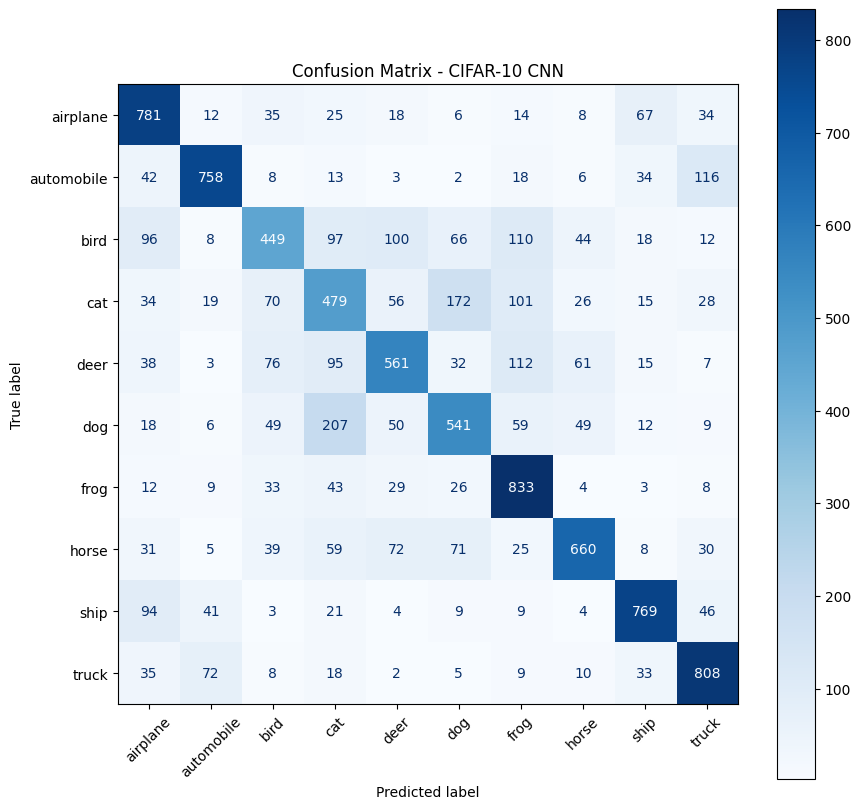

In [28]:
# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap='Blues'
)

plt.title("Confusion Matrix - CIFAR-10 CNN")
plt.show()

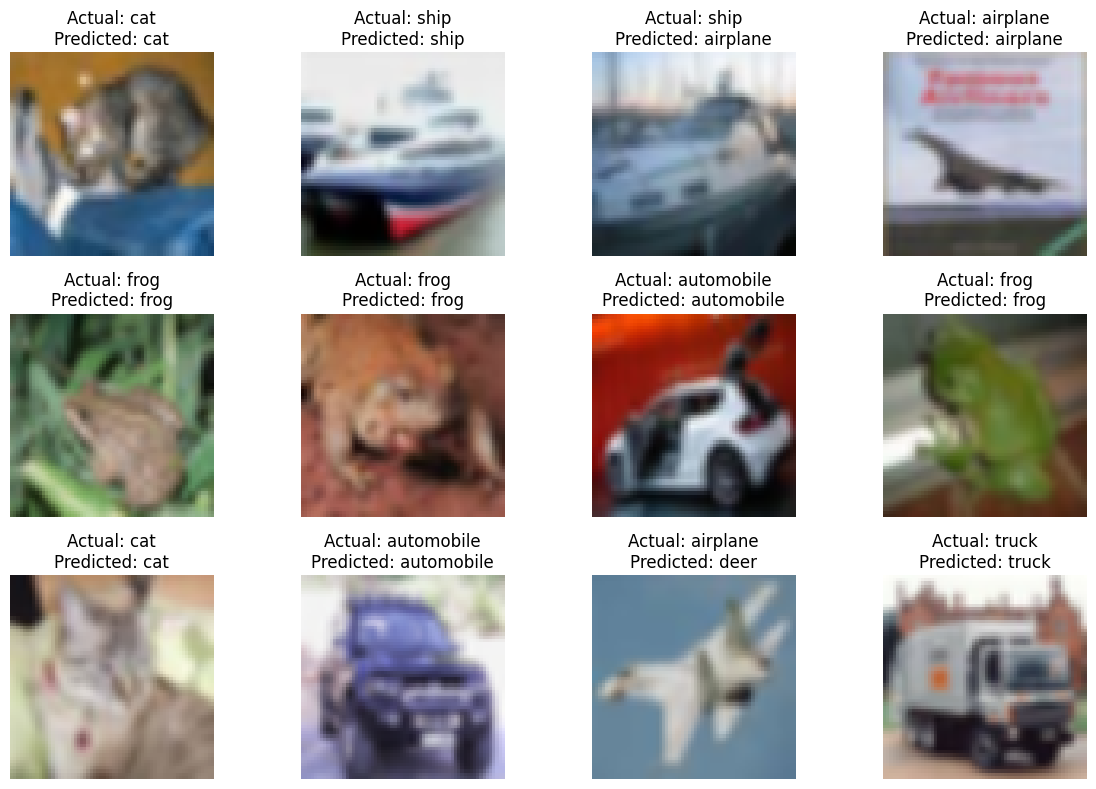

In [29]:
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[i])

    actual_label = class_names[y_true[i]]
    predicted_label = class_names[y_pred[i]]

    plt.title(
        f"Actual: {actual_label}\nPredicted: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
correct_indices = np.where(y_pred == y_true)[0]
incorrect_indices = np.where(y_pred != y_true)[0]

print("Number of correct predictions:", len(correct_indices))
print("Number of incorrect predictions:", len(incorrect_indices))

print(f"Correct prediction percentage: "
      f"{len(correct_indices) / len(y_true) * 100:.2f}%")

print(f"Incorrect prediction percentage: "
      f"{len(incorrect_indices) / len(y_true) * 100:.2f}%")

Number of correct predictions: 6639
Number of incorrect predictions: 3361
Correct prediction percentage: 66.39%
Incorrect prediction percentage: 33.61%


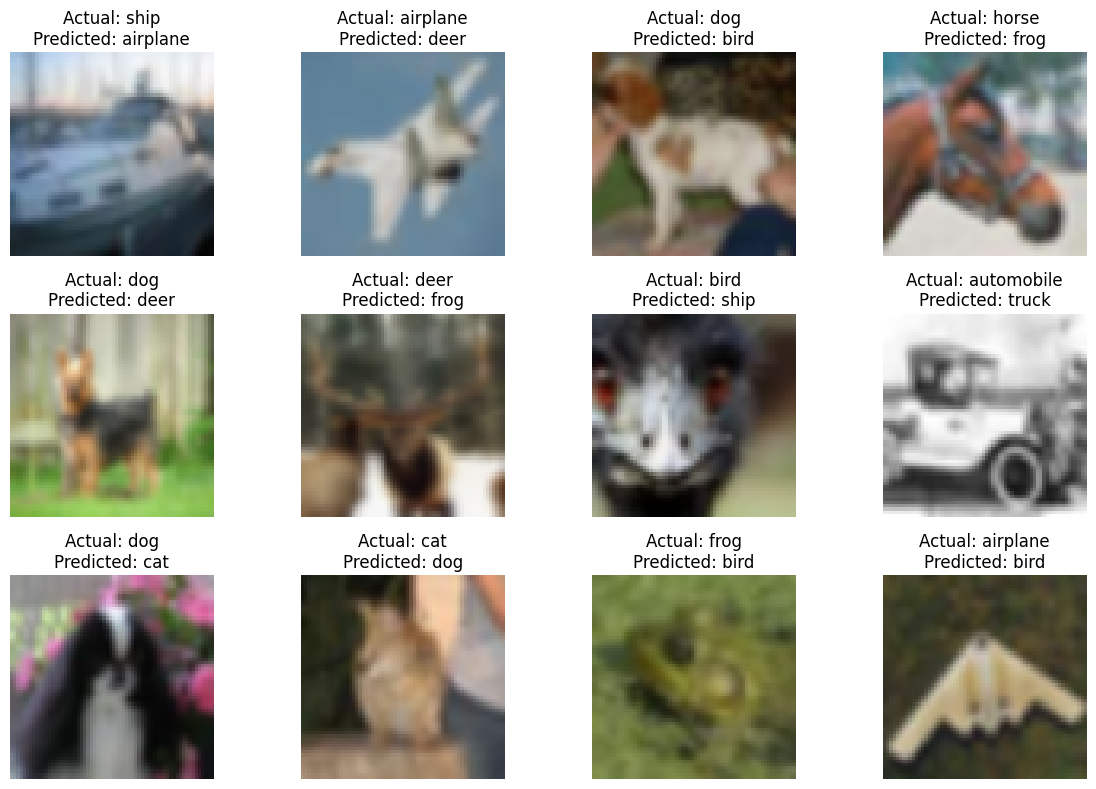

In [31]:
  plt.figure(figsize=(12, 8))

num_images = min(12, len(incorrect_indices))

for i in range(num_images):
    index = incorrect_indices[i]

    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[index])

    actual_label = class_names[y_true[index]]
    predicted_label = class_names[y_pred[index]]

    plt.title(
        f"Actual: {actual_label}\nPredicted: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:
# Copy confusion matrix and remove diagonal values
cm_off_diagonal = cm.copy()
np.fill_diagonal(cm_off_diagonal, 0)

# Find the location of the largest confusion
max_confusion = np.unravel_index(
    np.argmax(cm_off_diagonal),
    cm_off_diagonal.shape
)

actual_class = class_names[max_confusion[0]]
predicted_class = class_names[max_confusion[1]]
confusion_count = cm_off_diagonal[max_confusion]

print("Most confused class pair:")
print(f"Actual class     : {actual_class}")
print(f"Predicted class  : {predicted_class}")
print(f"Number of errors : {confusion_count}")

Most confused class pair:
Actual class     : dog
Predicted class  : cat
Number of errors : 207


##Strengths of CNNs for Image Classification

### Strengths

1. **Automatic Feature Extraction**  
   CNNs automatically learn useful features such as edges, textures, shapes, and patterns from images.

2. **High Image Classification Performance**  
   CNNs can achieve high accuracy on many image recognition tasks when sufficient training data is available.

3. **Parameter Sharing**  
   Convolutional filters are reused across different regions of an image, reducing the number of parameters compared with fully connected networks.

4. **Translation Tolerance**  
   CNNs can recognize important features even when their position changes within an image.

5. **Hierarchical Feature Learning**  
   Early layers learn simple features, while deeper layers learn more complex and meaningful patterns.

6. **Suitable for Large Image Datasets**  
   CNNs can effectively learn from large-scale image datasets and are widely used in computer vision applications.

##Limitations of CNNs for Image Classification

### Limitations

1. **Requires Large Amounts of Data**  
   CNNs generally require sufficient labeled training data to achieve good performance.

2. **High Computational Requirements**  
   Training deep CNNs can require significant CPU/GPU memory and processing power.

3. **Training Time**  
   Complex CNN architectures may take a long time to train.

4. **Overfitting**  
   CNNs can overfit the training data, especially when the dataset is small or the model is too complex.

5. **Sensitive to Image Quality**  
   Blurred, noisy, low-resolution, or poorly represented images can lead to incorrect predictions.

6. **Limited Interpretability**  
   It can be difficult to understand exactly why a CNN made a particular prediction.